In [1]:
import numpy as np #для матричных вычислений
import pandas as pd #для анализа и предобработки данных
import matplotlib.pyplot as plt #для визуализации
import seaborn as sns #для визуализации

from sklearn import linear_model #линейные модели
from sklearn import metrics #метрики
from sklearn import preprocessing #предобработка
from sklearn.model_selection import train_test_split #разделение выборки

In [4]:
data = pd.read_csv('C:\\Users\\Admin\\Desktop\\Data_pandas/insurance.csv')
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
print(data.shape)
# (1338, 7)

(1338, 7)


In [6]:
display(data.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
display(data.dtypes)

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [25]:
#кодируем бинарные категориальные признаки
data['smoker'] = data['smoker'].apply(lambda x: 0 if x == 'no' else 1)
data['sex'] = data['sex'].apply(lambda x: 0 if x == 'female' else 1)
#оставшиеся категориальные признаки кодируем с помощью OneHot
data = pd.get_dummies(data)
data.head()



,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,1,33.770,1,1,1725.55230,False,False,True,False
2,28,1,33.000,3,1,4449.46200,False,False,True,False
3,33,1,22.705,0,1,21984.47061,False,True,False,False
4,32,1,28.880,0,1,3866.85520,False,True,False,False


In [9]:
features = data.drop('charges', axis=1).columns
X, y = data[features], data['charges']

In [10]:
#Создаем тренировочную и тестовую выборки с помощью train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, #таблица с наблюдениями и столбец с правильным ответами
    test_size=0.2, #размер тестовой выборки
    random_state=42 #число отвечающее за генерацию случайных чисел
)
#Выводим размеры полученных выборок
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (1070, 9)
Test shape: (268, 9)


In [11]:
def print_metrics(y_train, y_train_predict, y_test, y_test_predict):
    print('Train R^2: {:.3f}'.format(metrics.r2_score(y_train, y_train_predict)))
    print('Train MAE: {:.3f}'.format(metrics.mean_absolute_error(y_train, y_train_predict)))
    print('Train MAPE: {:.3f}'.format(metrics.mean_absolute_percentage_error(y_train, y_train_predict)*100))
    print('\n')
    print('Test R^2: {:.3f}'.format(metrics.r2_score(y_test, y_test_predict)))
    print('Test MAE: {:.3f}'.format(metrics.mean_absolute_error(y_test, y_test_predict)))
    print('Train MAPE: {:.3f}'.format(metrics.mean_absolute_percentage_error(y_test, y_test_predict)*100))

In [27]:
from sklearn.linear_model import LinearRegression

# Обучаем модель линейной регрессии
model = LinearRegression()
model.fit(X, y)

# Получаем свободный член (intercept)
intercept = model.intercept_
print(f"Свободный член (intercept): {intercept:.2f}")

Свободный член (intercept): -12525.55


In [28]:
#Инициализируем объект класса линейная регрессия
lr = linear_model.LinearRegression()
#Обучаем модель - ищем параметры
lr.fit(X_train, y_train)
#Делаем предсказание для каждой из выборок
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)
#Выводим результирующие метрики
print_metrics(y_train, y_train_pred, y_test, y_test_pred)


Train R^2: 0.742
Train MAE: 4208.235
Train MAPE: 42.203


Test R^2: 0.784
Test MAE: 4181.194
Train MAPE: 46.888


<Figure size 1000x600 with 0 Axes>

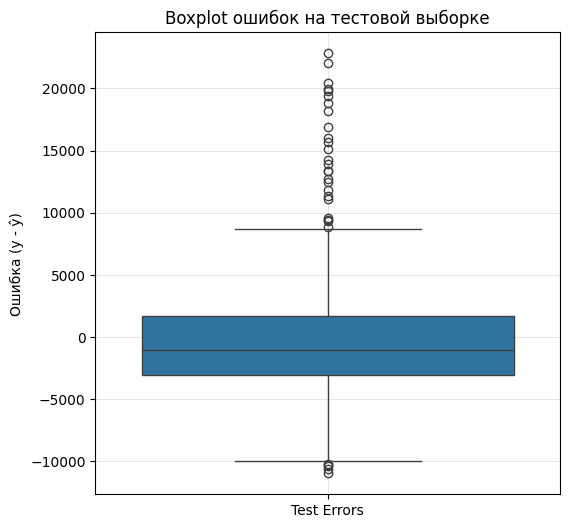

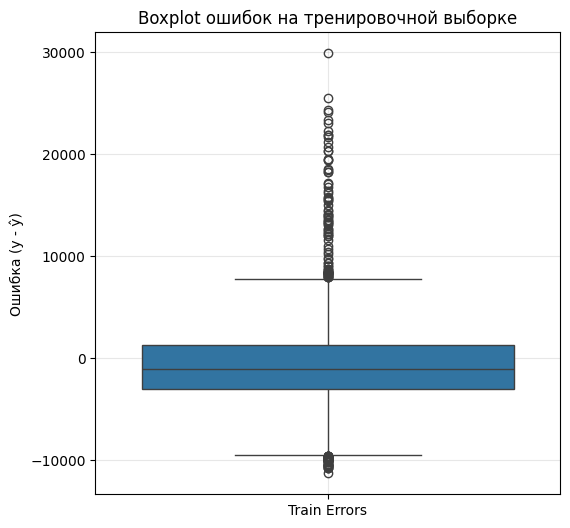

Средняя ошибка на тренировке: -0.00
Средняя ошибка на тесте: -158.28
Стандартное отклонение ошибок на тренировке: 6142.52
Стандартное отклонение ошибок на тесте: 5809.94


In [35]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Предполагаем, что данные уже загружены в X и y
# Если нет, раскомментируйте и адаптируйте строки ниже:
# from sklearn.datasets import make_regression
# X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)

# Разделяем данные на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Обучаем модель линейной регрессии
model = LinearRegression()
model.fit(X_train, y_train)

# Делаем предсказания
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Вычисляем ошибки (разница без модуля)
train_errors = y_train - y_train_pred
test_errors = y_test - y_test_pred

# Создаем boxplot
plt.figure(figsize=(10, 6))

# Первый вариант: используя seaborn (более красивый)
import matplotlib.pyplot as plt
import seaborn as sns

# Первый график для тестовых ошибок
plt.figure(figsize=(6, 6))
sns.boxplot(data=[test_errors])
plt.xticks([0], ['Test Errors'])  # исправлено: [0] вместо [1]
plt.title('Boxplot ошибок на тестовой выборке')
plt.ylabel('Ошибка (y - ŷ)')
plt.grid(True, alpha=0.3)
plt.show()

# Второй график для тренировочных ошибок
plt.figure(figsize=(6, 6))
sns.boxplot(data=[train_errors])
plt.xticks([0], ['Train Errors'])  # исправлено: [0] вместо [1]
plt.title('Boxplot ошибок на тренировочной выборке')
plt.ylabel('Ошибка (y - ŷ)')
plt.grid(True, alpha=0.3)
plt.show()




# Дополнительная информация
print(f"Средняя ошибка на тренировке: {np.mean(train_errors):.2f}")
print(f"Средняя ошибка на тесте: {np.mean(test_errors):.2f}")
print(f"Стандартное отклонение ошибок на тренировке: {np.std(train_errors):.2f}")
print(f"Стандартное отклонение ошибок на тесте: {np.std(test_errors):.2f}")

In [38]:
#Создаем объект для min-max нормализации
scaler = preprocessing.MinMaxScaler()
#Вычисляем параметры для нормализации - min и max для каждого столбца
scaler.fit(X_train)
#Производим преобразование для каждой из выборок
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Инициализируем объект класса линейная регрессия
sgd_lr = linear_model.SGDRegressor(random_state=42)
#Обучаем модель - ищем параметры
sgd_lr.fit(X_train_scaled, y_train)
#Делаем предсказание для каждой из выборок
y_train_pred = sgd_lr.predict(X_train_scaled)
y_test_pred = sgd_lr.predict(X_test_scaled)
#Выводим результирующие метрики
print_metrics(y_train, y_train_pred, y_test, y_test_pred)

Train R^2: 0.741
Train MAE: 4135.462
Train MAPE: 38.823


Test R^2: 0.769
Test MAE: 4011.082
Train MAPE: 39.534


In [37]:
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures

# Создаем объект MinMaxScaler и обучаем на тренировочных данных
scaler = MinMaxScaler()
X_train_normalized = scaler.fit_transform(X_train)  # fit + transform для тренировочных данных
X_test_normalized = scaler.transform(X_test)        # только transform для тестовых данных

# Создаем объект PolynomialFeatures степени 2 без свободного члена
poly = PolynomialFeatures(degree=2, include_bias=False)

# Генерируем полиномиальные признаки для нормализованных данных
X_train_poly = poly.fit_transform(X_train_normalized)  # fit + transform для тренировочных данных
X_test_poly = poly.transform(X_test_normalized)        # только transform для тестовых данных

# Проверяем размерности полученных данных
print(f"Исходная размерность X_train: {X_train.shape}")
print(f"Размерность X_train после нормализации: {X_train_normalized.shape}")
print(f"Размерность X_train после полиномиальных признаков: {X_train_poly.shape}")
print(f"Исходная размерность X_test: {X_test.shape}")
print(f"Размерность X_test после нормализации: {X_test_normalized.shape}")
print(f"Размерность X_test после полиномиальных признаков: {X_test_poly.shape}")

Исходная размерность X_train: (936, 9)
Размерность X_train после нормализации: (936, 9)
Размерность X_train после полиномиальных признаков: (936, 54)
Исходная размерность X_test: (402, 9)
Размерность X_test после нормализации: (402, 9)
Размерность X_test после полиномиальных признаков: (402, 54)


In [43]:
# Создаем объект PolynomialFeatures степени 2 без свободного члена
poly = PolynomialFeatures(degree=2, include_bias=False)

poly.fit(X_train_scaled)
#Генерируем полиномиальные признаки для тренировочной выборки
X_train_scaled_poly = poly.transform(X_train_scaled)
#Генерируем полиномиальные признаки для тестовой выборки
X_test_scaled_poly = poly.transform(X_test_scaled)
#Выводим результирующие размерности таблиц
 
print(X_train_scaled_poly.shape)
print(X_test_scaled_poly.shape)


(936, 54)
(402, 54)


In [45]:
#Создаём объект класса линейной регрессии с L1-регуляризацией
lasso_lr_poly = linear_model.Lasso(alpha=0.1, max_iter = 2000)
#Обучаем модель
lasso_lr_poly.fit(X_train_scaled_poly, y_train)
#Делаем предсказание для тренировочной выборки
y_train_predict_poly = lasso_lr_poly.predict(X_train_scaled_poly)
#Делаем предсказание для тестовой выборки
y_test_predict_poly = lasso_lr_poly.predict(X_test_scaled_poly)
#Рассчитываем коэффициент детерминации для двух выборок
print("Train R^2: {:.3f}".format(metrics.r2_score(y_train, y_train_predict_poly)))
print("Test R^2: {:.3f}".format(metrics.r2_score(y_test, y_test_predict_poly)))


Train R^2: 0.840
Test R^2: 0.861


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.138e+09, tolerance: 1.371e+07
  model = cd_fast.enet_coordinate_descent(


In [47]:
#Создаём объект класса линейной регрессии с L1-регуляризацией
lasso_lr_poly = linear_model.Lasso(alpha=0.1)
#Обучаем модель
lasso_lr_poly.fit(X_train_scaled_poly, y_train)
#Делаем предсказание для тренировочной выборки
y_train_predict_poly = lasso_lr_poly.predict(X_train_scaled_poly)
#Делаем предсказание для тестовой выборки
y_test_predict_poly = lasso_lr_poly.predict(X_test_scaled_poly)
#Рассчитываем коэффициент детерминации для двух выборок
print("Train R^2: {:.3f}".format(metrics.r2_score(y_train, y_train_predict_poly)))
print("Test R^2: {:.3f}".format(metrics.r2_score(y_test, y_test_predict_poly)))

# Train R^2: 0.879
# Test R^2: 0.882

Train R^2: 0.840
Test R^2: 0.861


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.864e+09, tolerance: 1.371e+07
  model = cd_fast.enet_coordinate_descent(


In [50]:
from sklearn import linear_model
from sklearn import metrics
import numpy as np

# Создаём объект класса линейной регрессии с L1-регуляризацией
lasso_lr_poly = linear_model.Lasso(alpha=1.0, max_iter=2000)

# Обучаем модель
lasso_lr_poly.fit(X_train_scaled_poly, y_train)

# Делаем предсказание для тестовой выборки
y_test_predict_poly = lasso_lr_poly.predict(X_test_scaled_poly)

# Рассчитываем все метрики на тестовой выборке
mae_test = metrics.mean_absolute_error(y_test, y_test_predict_poly)
mse_test = metrics.mean_squared_error(y_test, y_test_predict_poly)
r2_test = metrics.r2_score(y_test, y_test_predict_poly)

# Рассчитываем MAPE вручную (в sklearn нет встроенной функции)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_test = mean_absolute_percentage_error(y_test, y_test_predict_poly)

# Выводим все метрики с округлением
print("Метрики на тестовой выборке:")
print("MAE: {:.0f}".format(mae_test))
print("MSE: {:.0f}".format(mse_test))
print("R^2: {:.3f}".format(r2_test))
print("MAPE: {:.3f}%".format(mape_test))

Метрики на тестовой выборке:
MAE: 2678
MSE: 20389143
R^2: 0.861
MAPE: 28.960%


In [52]:
from sklearn import linear_model
from sklearn import metrics
import numpy as np

# Создаём объект класса линейной регрессии с L2-регуляризацией
lasso_lr_poly = linear_model.Ridge(alpha=1.0, max_iter=2000)

# Обучаем модель
lasso_lr_poly.fit(X_train_scaled_poly, y_train)

# Делаем предсказание для тестовой выборки
y_test_predict_poly = lasso_lr_poly.predict(X_test_scaled_poly)

# Рассчитываем все метрики на тестовой выборке
mae_test = metrics.mean_absolute_error(y_test, y_test_predict_poly)
mse_test = metrics.mean_squared_error(y_test, y_test_predict_poly)
r2_test = metrics.r2_score(y_test, y_test_predict_poly)

# Рассчитываем MAPE вручную (в sklearn нет встроенной функции)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_test = mean_absolute_percentage_error(y_test, y_test_predict_poly)

# Выводим все метрики с округлением
print("Метрики на тестовой выборке:")
print("MAE: {:.0f}".format(mae_test))
print("MSE: {:.0f}".format(mse_test))
print("R^2: {:.3f}".format(r2_test))
print("MAPE: {:.3f}%".format(mape_test))

Метрики на тестовой выборке:
MAE: 2810
MSE: 21046587
R^2: 0.856
MAPE: 29.647%
